#### Parcel maps

Creates map of parcels in each watershed.

In [1]:
from pathlib import Path
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box

# get filepath 
cd = Path.cwd() 

# create folder to store clean data 
out_dir = Path(f"{cd}/Figures/Parcel_maps")
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
##### ---------- IMPORT GEO BOUNDARIES ----------

# parcel  boundaries
GBSJ_parcels = gpd.read_file("/netfiles/ciroh/data/social_water_use/Parcels/GBSJ_with_ID.shp")
LCRR_parcels = gpd.read_file("/netfiles/ciroh/data/social_water_use/Parcels/LCRR_with_ID.shp")
MILK_parcels = gpd.read_file("/netfiles/ciroh/data/social_water_use/Parcels/MILK_with_ID.shp")

# huc12 boundaries 
GBSJ_basin = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/GBSJ_basin.shp")
LCRR_basin = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/LCRR_basin.shp")
MILK_basin = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/MILK_basin.shp")

# prep CRS for maps
target_crs = GBSJ_basin.crs

LCRR_basin = LCRR_basin.to_crs(target_crs)
MILK_basin = MILK_basin.to_crs(target_crs)
GBSJ_parcels = GBSJ_parcels.to_crs(target_crs)
LCRR_parcels = LCRR_parcels.to_crs(target_crs)
MILK_parcels = MILK_parcels.to_crs(target_crs)

In [3]:
##### ---------- PREP DATA FOR MAPING -----------

# Asign random color to each parcel 

palette = [
    "#A8DADC", "#F4A6A6", "#B8E1A1", "#FFD59E",
    "#C9B8E8", "#F7E29E", "#A6C8E8", "#F2B5D4",
    "#D8C9A3", "#B0E0D3",
]

rng = np.random.default_rng(seed=42)

colors_GBSJ = rng.choice(palette, size=len(GBSJ_parcels))
colors_LCRR = rng.choice(palette, size=len(LCRR_parcels))
colors_MILK = rng.choice(palette, size=len(MILK_parcels))

GBSJ_parcels = GBSJ_parcels.copy()
LCRR_parcels = LCRR_parcels.copy()
MILK_parcels = MILK_parcels.copy()

GBSJ_parcels["color"] = colors_GBSJ
LCRR_parcels["color"] = colors_LCRR
MILK_parcels["color"] = colors_MILK

/tmp/ipykernel_1722061/3565035773.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])


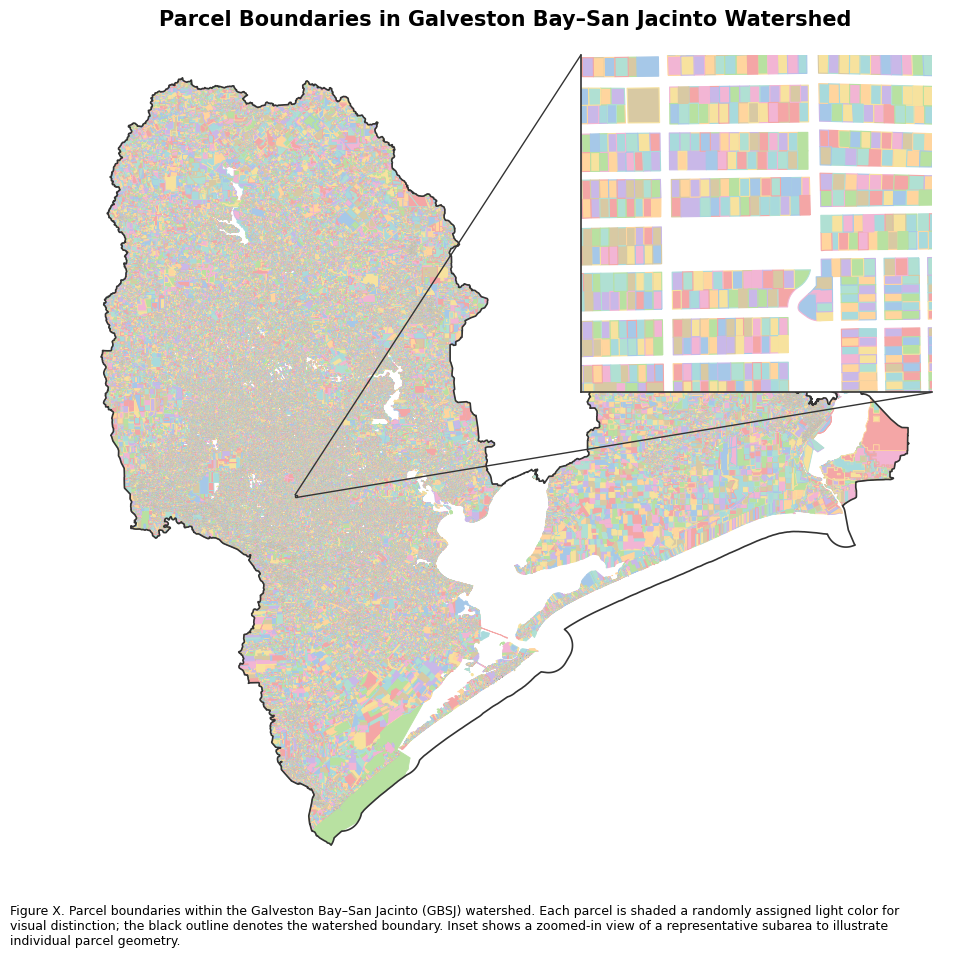

In [11]:
##### --------- MAP PARCELS ----------

### ------ MANUAL INPUTS ----- 

# set figure to plot 
parcels = GBSJ_parcels.copy() # GBSJ_parcels, LCRR_parcels, MILK_parcels
basin = GBSJ_basin.copy() # GBSJ_basin, LCRR_basin, MILK_basin
watershed = 'Galveston Bay–San Jacinto' # Galveston Bay–San Jacinto, Lake Champlain–Richelieu River, or Milk River
watershed_code = 'GBSJ' #GBSJ, LCRR, or MILK

# set b_box 
# GBSJ = (-95.42628,29.71825,-95.41995,29.72354)
# LCRR = (-73.22752,44.47441,-73.21469,44.48359)
# MILK = (-109.78792,48.50831,-109.60905,48.61946)
bbox_wgs84 = box(-95.42628,29.71825,-95.41995,29.72354)

### ------ SET STYLE ----- 

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

### ----- PLOT -----
fig, ax = plt.subplots(figsize=(10, 10)) # change to 10,6 for MILK

### Plot parcels
parcels.plot(
    ax=ax,
    color=parcels["color"],
    edgecolor=parcels["color"],
    linewidth=0.6,
)

# basin outline, styled to match watershed outline in choropleth figure
basin.boundary.plot(ax=ax, color="#333333", linewidth=1.2)

ax.set_title(
    f"Parcel Boundaries in {watershed} Watershed",
    fontsize=15, fontweight='bold', pad=10
)
ax.set_axis_off()

### Plot inset 

# reproject bbox to target_crs
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_wgs84], crs="EPSG:4326").to_crs(target_crs)
minx, miny, maxx, maxy = bbox_gdf.total_bounds

# put inset in upper-right corner
axins = inset_axes(
    ax,
    width="40%",   
    height="40%",
    loc="upper right",
    borderpad=1,
)

parcels.plot(
    ax=axins,
    color=parcels["color"],
    edgecolor=parcels["color"],
    linewidth=0.8,
)

basin.boundary.plot(ax=axins, color="#333333", linewidth=1.2)

axins.set_xlim(minx, maxx)
axins.set_ylim(miny, maxy)
axins.set_xticks([])
axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_edgecolor("#333333")
    spine.set_linewidth(1.2)

# draw a rectangle on the main map showing the inset's extent
rect, c1, c2 = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="#333333", lw=1)
rect.set_clip_on(False)
c1.set_clip_on(False)
c2.set_clip_on(False)

# make sure connector lines/rectangle draw ON TOP of the parcels/basin fill
rect.set_zorder(10)
c1.set_zorder(10)
c2.set_zorder(10)

### ----- CAPTION (matches choropleth figure's caption style) -----
caption_text = (
    f"Figure X. Parcel boundaries within the {watershed} ({watershed_code}) watershed. Each parcel is shaded a randomly assigned light color for \n"
    f"visual distinction; the black outline denotes the watershed boundary. Inset shows a zoomed-in view of a representative subarea to illustrate\n"
    f"individual parcel geometry."
)
fig.text(0.02, 0.012, caption_text, ha='left', va='bottom', fontsize=9, wrap=True)
fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])

plt.savefig(out_dir / f"{watershed_code}_parcel_map_with_inset.png", dpi=300, bbox_inches="tight")
plt.show()